# Library Imports and Utilities

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def preprocess_dataset(df):
    # 1. Remove features with a single value (constant features)
    constant_cols = []
    for col in df.columns:
        try:
            if df[col].nunique() == 1:
                constant_cols.append(col)
        except:
            pass

    if constant_cols:
        print(f"Constant features were removed: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("No constant features were found")

    # 2. Remove rows with missing values
    df_clean = df.dropna()

    # 3. Remove duplicate rows
    df_clean = df_clean.drop_duplicates()

    print(f"Size after preprocessing: {df_clean.shape}")
    return df_clean

def replace_target(y):
    '''
    If the number of class 0 instances is less than class 1, the class labels are swapped (0 and 1).
    '''
    return 1 - y if (y == 0).sum() < (y == 1).sum() else y

# Loading the Dataset

The Credit Card Fraud Detection dataset is a widely used benchmark for anomaly detection in financial transactions, made publicly available through a Kaggle competition. It consists of credit card transactions made by European cardholders in September 2013 over a two‑day period. The dataset contains 284,807 transactions, of which 492 are fraudulent, giving a fraud rate of approximately 0.172 %. To protect cardholders’ privacy, the 28 numerical features V1 … V28 are the result of a Principal Component Analysis (PCA) transformation. Two features were left untransformed: the transaction Amount and the Time elapsed since the first recorded transaction. The target variable is Class (also named Label in some versions), where 1 indicates fraud and 0 a legitimate transaction.
Due to the strong class imbalance, the dataset is particularly challenging for standard classifiers; models often require resampling techniques (e.g., SMOTE) or cost‑sensitive learning to achieve good performance. Despite its imbalance, the dataset has become a reference benchmark for evaluating fraud detection algorithms, ranging from logistic regression and tree‑based ensembles to deep learning architectures.
We used the Credit Card Fraud Detection dataset, which contains 283 726 instances with a 0,17 % anomaly rate. It comprises 30 numerical and 0 categorical features. The data were used after preprocessing (missing values, duplicates, and constant features were removed). F1 and Recall scores were obtained with a threshold of 0.5. We used 59 984 instances for finetuning, of which 100 were anomalies, and the same number (59 984  instances, 100 anomalies) for testing.

In [4]:
import os
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_path = None
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_path = os.path.join(path, file)
        break

if csv_path:
    df_raw = pd.read_csv(csv_path)
    print(f"Data loaded. Shape: {df_raw.shape}")
else:
    print("CSV file not found")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Data loaded. Shape: (284807, 31)


# Preprocessing

In [5]:
df_raw.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
X = preprocess_dataset(df_raw.drop(columns=['Class']))
y = (df_raw['Class']).astype(int).loc[X.index].squeeze()
y = replace_target(y)

No constant features were found
Size after preprocessing: (283726, 30)


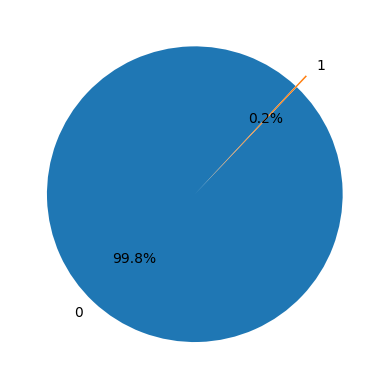

In [7]:
plt.pie(
    [y[y==0].shape[0], y[y==1].shape[0]],
    autopct='%1.1f%%',
    explode=(0, 0.1),
    labels=['0', '1'],
    startangle=47
)
plt.show();

In [8]:
unique, counts = np.unique(y, return_counts=True)
print(f"Класс 0 : {counts[0]}")
print(f"Класс 1 : {counts[1]}")

Класс 0 : 283253
Класс 1 : 473


In [9]:
unique_counts = pd.DataFrame.from_records([(col, X[col].unique(), X[col].nunique(), X[col].dtypes) for col in X.columns],
                                          columns=['Name', 'Values', 'Count of values', 'Type']).sort_values(by=['Count of values', 'Name'])
unique_counts

,Name,Values,Count of values,Type
29,Amount,"[149.62, 2.69, 378.66, 123.5, 69.99, 3.67, 4.9...",32767,float64
0,Time,"[0.0, 1.0, 2.0, 4.0, 7.0, 9.0, 10.0, 11.0, 12....",124592,float64
1,V1,"[-1.3598071336738, 1.19185711131486, -1.358354...",275663,float64
10,V10,"[0.0907941719789316, -0.166974414004614, 0.207...",275663,float64
11,V11,"[-0.551599533260813, 1.61272666105479, 0.62450...",275663,float64
12,V12,"[-0.617800855762348, 1.06523531137287, 0.06608...",275663,float64
13,V13,"[-0.991389847235408, 0.48909501589608, 0.71729...",275663,float64
14,V14,"[-0.311169353699879, -0.143772296441519, -0.16...",275663,float64
15,V15,"[1.46817697209427, 0.635558093258208, 2.345864...",275663,float64
16,V16,"[-0.470400525259478, 0.463917041022171, -2.890...",275663,float64


In [10]:
num_cols = X.columns.tolist()
cat_cols = []